In [1]:
import os

os.environ["KERAS_BACKEND"] = "jax"

In [2]:
from pathlib import Path
import random

import grain.python as grain
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import keras

In [3]:
DATA_DIR = Path("data/oxford-iiit-pet")
IMAGES_DIR = DATA_DIR / "images"
LABELS_DIR = DATA_DIR / "annotations" / "trimaps"
LIST_FILE = DATA_DIR / "annotations" / "list.txt"

BATCH_SIZE = 16
TARGET_SIZE = (160, 160)
N_CLASSES = 3

In [ ]:
stems = [
    line.split()[0]
    for line in LIST_FILE.read_text().splitlines()
    if line and not line.startswith("#")
]
stems = [
    s
    for s in stems
    if (IMAGES_DIR / f"{s}.jpg").exists() and (LABELS_DIR / f"{s}.png").exists()
]
stems.sort()

n = len(stems)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

train_stems = stems[:n_train]
val_stems = stems[n_train : n_train + n_val]
test_stems = stems[n_train + n_val :]

train_imgs = [IMAGES_DIR / f"{s}.jpg" for s in train_stems]
train_msks = [LABELS_DIR / f"{s}.png" for s in train_stems]
val_imgs = [IMAGES_DIR / f"{s}.jpg" for s in val_stems]
val_msks = [LABELS_DIR / f"{s}.png" for s in val_stems]
test_imgs = [IMAGES_DIR / f"{s}.jpg" for s in test_stems]
test_msks = [LABELS_DIR / f"{s}.png" for s in test_stems]

steps_train = len(train_imgs) // BATCH_SIZE
steps_val = len(val_imgs) // BATCH_SIZE

print(
    f"Total: {n}  |  Train: {len(train_imgs)}  |  Val: {len(val_imgs)}  |  Test: {len(test_imgs)}"
)
print(f"Steps - train: {steps_train}  val: {steps_val}")

Total: 7349  |  Train: 5144  |  Val: 1102  |  Test: 1103
Steps — train: 321  val: 68


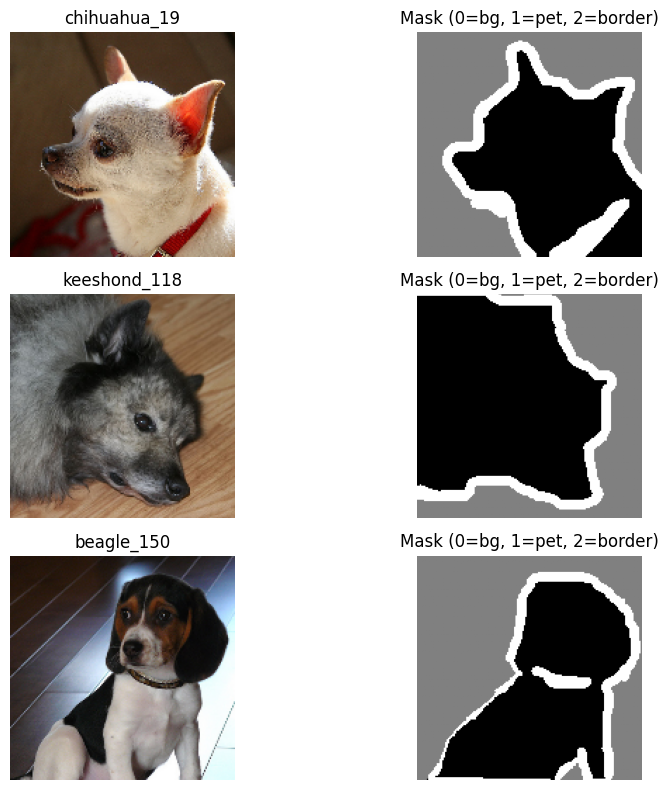

In [5]:
sample_stems = random.sample(train_stems, 3)

plt.figure(figsize=(10, 8))
for i, stem in enumerate(sample_stems):
    img = keras.preprocessing.image.smart_resize(
        np.array(
            Image.open(IMAGES_DIR / f"{stem}.jpg").convert("RGB"), dtype=np.float32
        )
        / 255.0,
        TARGET_SIZE,
    )
    msk_arr = np.array(Image.open(LABELS_DIR / f"{stem}.png"), dtype=np.int32)[
        ..., np.newaxis
    ]
    msk = (
        keras.preprocessing.image.smart_resize(
            msk_arr, TARGET_SIZE, interpolation="nearest"
        )[..., 0]
        - 1
    )

    ax = plt.subplot(3, 2, 2 * i + 1)
    ax.imshow((img * 255).astype("uint8"))
    ax.set_title(stem)
    ax.axis("off")

    ax = plt.subplot(3, 2, 2 * i + 2)
    ax.imshow(msk, cmap="gray")
    ax.set_title("Mask (0=bg, 1=pet, 2=border)")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
class PetDataSource(grain.RandomAccessDataSource):
    def __init__(self, img_paths, msk_paths):
        self.img_paths = img_paths
        self.msk_paths = msk_paths

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_arr = (
            np.array(Image.open(self.img_paths[idx]).convert("RGB"), dtype=np.float32)
            / 255.0
        )
        img = keras.preprocessing.image.smart_resize(img_arr, TARGET_SIZE)

        msk_arr = np.array(Image.open(self.msk_paths[idx]), dtype=np.int32)[
            ..., np.newaxis
        ]
        msk = keras.preprocessing.image.smart_resize(
            msk_arr, TARGET_SIZE, interpolation="nearest"
        )
        msk = (msk[..., 0] - 1)[..., np.newaxis].astype(np.uint8)
        return img, msk

    def __repr__(self):
        return f"PetDataSource(n={len(self)})"


def make_loader(img_paths, msk_paths, shuffle, num_epochs=None):
    source = PetDataSource(img_paths, msk_paths)
    sampler = grain.IndexSampler(
        num_records=len(source),
        shard_options=grain.NoSharding(),
        shuffle=shuffle,
        num_epochs=num_epochs,
        seed=42,
    )
    return grain.DataLoader(
        data_source=source,
        sampler=sampler,
        worker_count=0,
        operations=[grain.Batch(BATCH_SIZE, drop_remainder=True)],
    )


train_loader = make_loader(train_imgs, train_msks, shuffle=True)
val_loader = make_loader(val_imgs, val_msks, shuffle=False)
test_loader = make_loader(test_imgs, test_msks, shuffle=False, num_epochs=1)

# Verify shapes
x_batch, y_batch = next(iter(train_loader))
print(f"Images: {x_batch.shape}  dtype={x_batch.dtype}")
print(
    f"Masks:  {y_batch.shape}  dtype={y_batch.dtype}  unique={set(y_batch.ravel().tolist())}"
)

Images: (16, 160, 160, 3)  dtype=float32
Masks:  (16, 160, 160, 1)  dtype=uint8  unique={0, 1, 2}
